#Main Code Notebook group 15 coursework 1 CS3IV


In [26]:
#install required modules
# !pip install opencv-python
# !pip install matplotlib

#file paths in the cell below will need to be changed btw

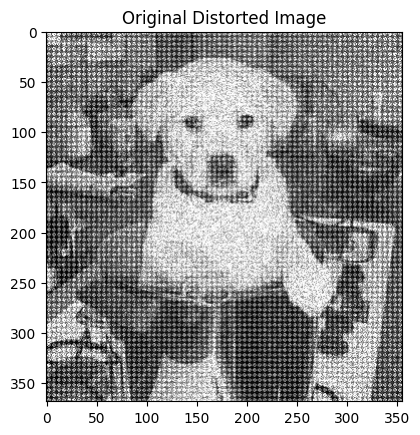

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the images
img = cv2.imread('/content/drive/MyDrive/cs3iv /dogDistorted.bmp', 0)
img_original = cv2.imread('/content/drive/MyDrive/cs3iv /dogOriginal.bmp', 0)

# 2. Safety check to make sure the image actually loaded
if img is None:
    print("Error: Could not find 'DogDistorted.bmp'")
else:
    # 3. Display the image
    plt.imshow(img, cmap='gray')
    plt.title('Original Distorted Image')
    plt.show()

#Step 1, FFT



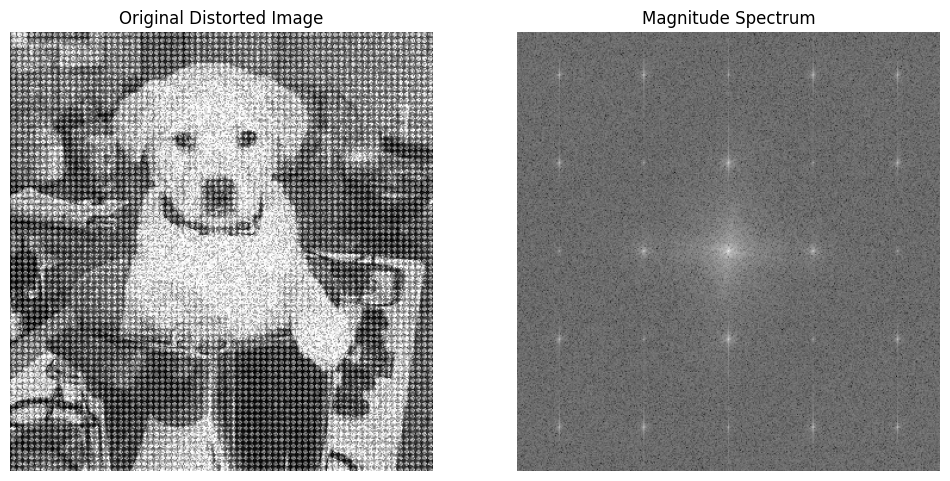

In [28]:
# --- CELL 2: COMPUTE FFT AND DISPLAY MAGNITUDE SPECTRUM ---

# 1. Compute the 2-Dimensional Fast Fourier Transform (FFT)
# Converts the image from the spatial domain (pixels) to the frequency domain
f = np.fft.fft2(img)

# 2. Shift the zero-frequency component (DC component) to the center of the spectrum
# This makes it much easier to visualize and design filters
fshift = np.fft.fftshift(f)

# 3. Calculate the magnitude spectrum
# np.abs is used to get the magnitude of complex numbers.
# 20 * np.log() is used to scale the values so human eyes can see the data.
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) # (+1 is to avoid taking the log of 0)

# 4. Display the original image and its frequency spectrum
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Original Distorted Image'), plt.axis('off')

plt.subplot(122)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.axis('off')

plt.show()



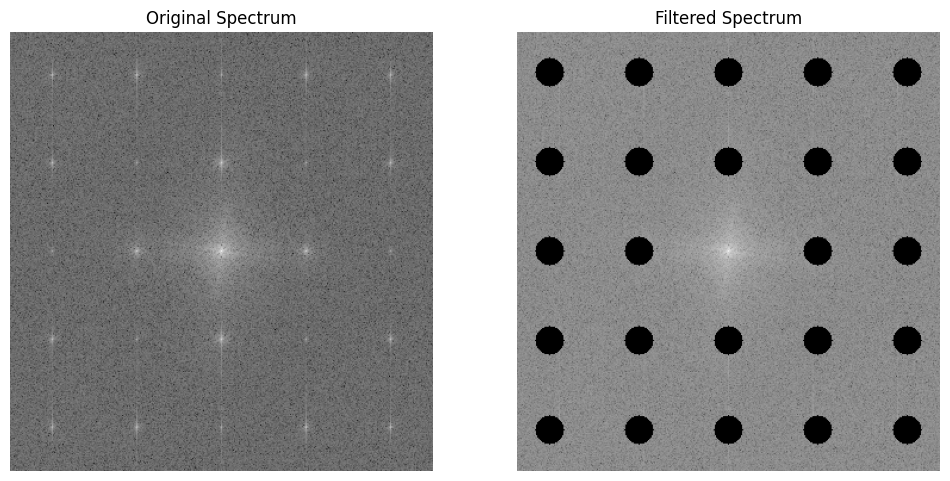

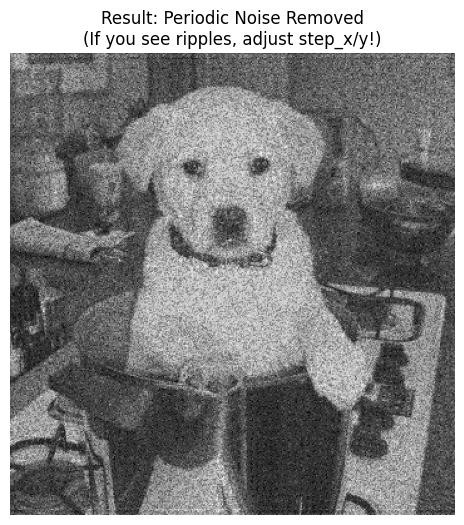

Image saved


In [29]:
# --- CELL 3: 5x5 NOTCH FILTER  ---

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# 1. Initialize the Notch Mask with 1s (Allow all frequencies to pass initially)
mask_notch = np.ones((rows, cols), np.uint8)

# 2. Set radius and position of the notches
r = 12  # Must be able to cover star but not too big to blur image.

step_y = 75  # Vertical distance between stars, tweaked until they lined up with the white stars, 75 works
step_x = 75  # Horizontal distance between stars

# 4. Loop to create a 5x5 grid of notches
for i in[-2, -1, 0, 1, 2]:
    for j in[-2, -1, 0, 1, 2]:
        # Must not block center
        if i == 0 and j == 0:
            continue

        # Calculate the center of each notch
        y = int(crow + (i * step_y))
        x = int(ccol + (j * step_x))

        # Draw a black circle (0) at that location
        cv2.circle(mask_notch, (x, y), r, 0, -1)

# 5. Apply the mask to the shifted FFT
fshift_notch = fshift * mask_notch

# --- VISUAL ALIGNMENT CHECK ---
# Check the spectrum after the mask is applied to ensure the stars are gone
magnitude_spectrum_filtered = 20 * np.log(np.abs(fshift_notch) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Original Spectrum'), plt.axis('off')

plt.subplot(122)
plt.imshow(magnitude_spectrum_filtered, cmap='gray')
plt.title('Filtered Spectrum')
plt.axis('off')
plt.show()

# 6. Inverse FFT Process (Convert back to an image)
f_ishift_notch = np.fft.ifftshift(fshift_notch)
img_notch = np.fft.ifft2(f_ishift_notch)
img_notch = np.abs(img_notch)

# 7. display cleaned image
plt.figure(figsize=(8, 6))
plt.imshow(img_notch, cmap='gray')
plt.title('Result: Periodic Noise Removed\n(If you see ripples, adjust step_x/y!)')
plt.axis('off')
plt.show()

# Save for future steps
cv2.imwrite('Dog_Periodic_Removed.bmp', img_notch.astype(np.uint8))
print("Image saved")

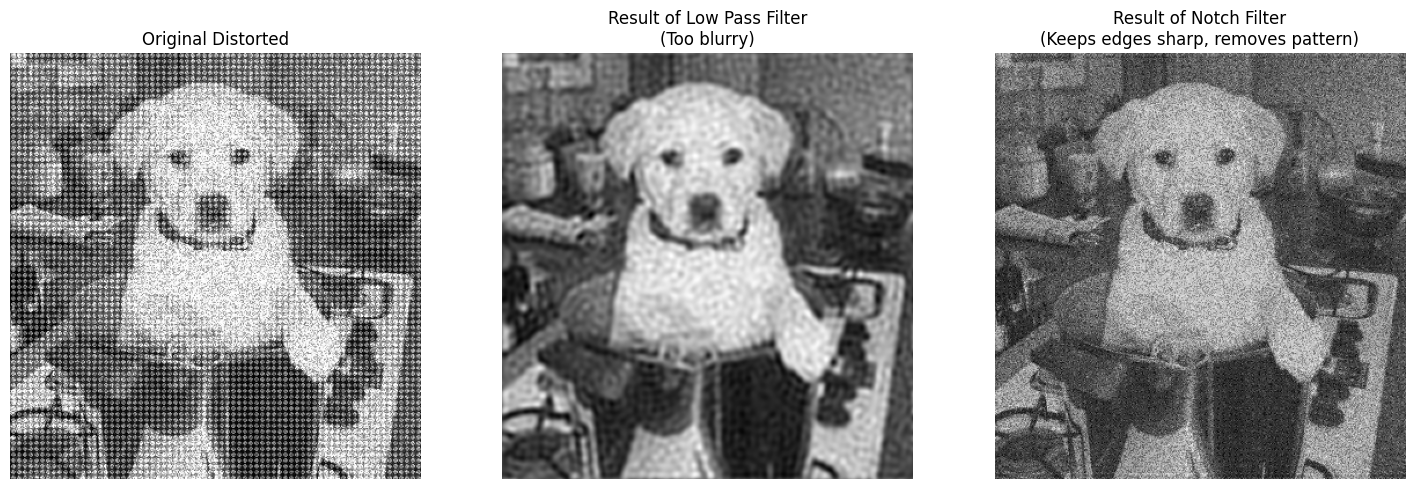

In [30]:
# --- CELL 4: COMPARISON WITH IDEAL LOW PASS FILTER (ILPF) ---
# this will smooth over the distortion by blurring everthing, results will probably show that the FFT and


# 1. Design an Ideal Low Pass Filter (ILPF)
# This blocks ALL high frequencies, not just the noise spikes.
mask_ilpf = np.zeros((rows, cols), np.uint8)
cutoff_radius = 50 # Only allow frequencies within this radius to pass
cv2.circle(mask_ilpf, (ccol, crow), cutoff_radius, 1, -1)

# 2. Apply ILPF mask and perform Inverse FFT
fshift_ilpf = fshift * mask_ilpf
f_ishift_ilpf = np.fft.ifftshift(fshift_ilpf)
img_ilpf = np.abs(np.fft.ifft2(f_ishift_ilpf))

# 3. Display Side-by-Side Comparison
plt.figure(figsize=(18, 6))

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Original Distorted'), plt.axis('off')

plt.subplot(132), plt.imshow(img_ilpf, cmap='gray')
plt.title('Result of Low Pass Filter\n(Too blurry)'), plt.axis('off')

plt.subplot(133), plt.imshow(img_notch, cmap='gray')
plt.title('Result of Notch Filter\n(Keeps edges sharp, removes pattern)'), plt.axis('off')

plt.show()


The currently filtered image is saved as Dog_Periodic_Removed.bmp

#Step 2, Spatial Filtering

#Step 3 Evaluation and Results